In [ ]:
import os
import pandas as pd

ON_KAGGLE = os.path.exists('/kaggle/input')

if ON_KAGGLE:
    ball_by_ball_data = pd.read_csv('/kaggle/input/ipl-dataset-2008-to-2025/ball_by_ball_data.csv')
    ipl_matches_data  = pd.read_csv('/kaggle/input/ipl-dataset-2008-to-2025/ipl_matches_data.csv')
    teams_data        = pd.read_csv('/kaggle/input/ipl-dataset-2008-to-2025/teams_data.csv')
    players_data      = None  # not in this Kaggle dataset
else:
    ball_by_ball_data = pd.read_csv('./ipl-dataset-2008-to-2025/ball_by_ball_data.csv')
    ipl_matches_data  = pd.read_csv('./ipl-dataset-2008-to-2025/ipl_matches_data.csv')
    players_data      = pd.read_csv('./ipl-dataset-2008-to-2025/players-data-updated.csv')
    teams_data        = pd.read_csv('./ipl-dataset-2008-to-2025/teams_data.csv')

In [39]:
from IPython.display import Markdown, display

_files = [
    (ball_by_ball_data,  "ball_by_ball_data.csv",    "One row per ball delivered"),
    (ipl_matches_data,   "ipl_matches_data.csv",     "One row per match"),
    (players_data,       "players-data-updated.csv", "Player registry"),
    (teams_data,         "teams_data.csv",            "Team ID → name lookup"),
]

_seasons = sorted(ball_by_ball_data["season_id"].unique())
_season_min, _season_max = int(_seasons[0]), int(_seasons[-1])
_n_seasons = len(_seasons)
_latest_match = pd.to_datetime(ipl_matches_data["match_date"]).max().strftime("%d %b %Y")

_rows = ["| File | Rows | Columns | Description |", "|------|------|---------|-------------|"]
for df, name, desc in _files:
    _rows.append(f"| `{name}` | {len(df):,} | {len(df.columns)} | {desc} |")

_table = "\n".join(_rows)

display(Markdown(f"""
# Dataset Notes — IPL {_season_min}–{_season_max}

## Files
{_table}

## Seasons covered
{_season_min} through {_season_max} ({_n_seasons} seasons). `season_id` is the 4-digit year.

**Latest match in dataset:** {_latest_match}

## Key ID/Foreign-key relationships
- `ball_by_ball_data.match_id` → `ipl_matches_data.match_id`
- `ball_by_ball_data.team_batting` / `team_bowling` → `teams_data.team_id`
- `ipl_matches_data.team1`, `team2`, `match_winner`, `toss_winner` → `teams_data.team_id`
- Players in `ball_by_ball_data` are stored as **name strings** (`batter`, `bowler`, `non_striker`), NOT player IDs
- `players_data.player_name` matches those name strings

## ball_by_ball_data — important columns
| Column | Type | Notes |
|--------|------|-------|
| `season_id` | int | Year ({_season_min}–{_season_max}) |
| `match_id` | int | FK to ipl_matches_data |
| `batter`, `bowler`, `non_striker` | str | Player name strings |
| `team_batting`, `team_bowling` | int | FK to teams_data |
| `over_number` | int | 0-indexed (0–19) |
| `ball_number` | int | 0-indexed within over |
| `batter_runs` | int | Runs scored by batter off that ball |
| `extras` | int | Total extras on that ball |
| `total_runs` | int | batter_runs + extras |
| `is_wicket` | bool | True if a wicket fell |
| `wicket_kind` | str | NaN when no wicket; values: caught, bowled, run out, lbw, caught and bowled, stumped, hit wicket, etc. |
| `player_out` | str | NaN when no wicket |
| `is_wide_ball`, `is_no_ball` | bool | Extras flags |
| `is_super_over` | bool | True for super over deliveries |
| `innings` | int | 1 or 2 for normal; 3–6 for super overs |
| `batsman_type`, `bowler_type` | str | ~239/339 nulls respectively |

## ipl_matches_data — important columns
| Column | Type | Notes |
|--------|------|-------|
| `match_date` | str | ISO date string (YYYY-MM-DD) — parse with `pd.to_datetime` |
| `venue`, `city` | str | city has 51 nulls |
| `match_winner` | int | FK to teams_data; 0 = no result/tie |
| `win_by_runs` | float | NaN if won by wickets |
| `win_by_wickets` | float | NaN if won by runs |
| `result` | str | 'win', 'tie', 'no result' |
| `toss_decision` | str | 'field' or 'bat' |
| `player_of_match` | float | player_id (9 nulls) |

## Teams (all {len(teams_data)} franchises incl. defunct)
```
1   Royal Challengers Bangalore    6   Kolkata Knight Riders
2   Sunrisers Hyderabad          129   Chennai Super Kings
3   Mumbai Indians               134   Rajasthan Royals
4   Rising Pune Supergiant       252   Delhi Capitals
5   Gujarat Lions                494   Punjab Kings
614 Lucknow Super Giants         615   Gujarat Titans
1068 Deccan Chargers            1414   Kochi Tuskers Kerala
1419 Pune Warriors             3604   Rising Pune Supergiants
```

## Common join patterns
```python
# Merge team names into matches
matches_with_teams = ipl_matches_data.merge(teams_data, left_on='match_winner', right_on='team_id', how='left')

# Ball-level with team names
ball_with_teams = ball_by_ball_data.merge(teams_data.rename(columns={{'team_id':'team_batting','team_name':'batting_team'}}), on='team_batting', how='left')

# Filter out super overs
normal_balls = ball_by_ball_data[~ball_by_ball_data['is_super_over']]

# Legal deliveries (for economy/strike rate)
legal = ball_by_ball_data[~ball_by_ball_data['is_wide_ball'] & ~ball_by_ball_data['is_no_ball']]
```

## Watchouts
- **Team IDs are not sequential** — use `teams_data` for every name lookup
- **`over_number` is 0-indexed** (0 = first over; add 1 for display)
- **Extras don't credit the batter** — use `batter_runs` for batting stats, `total_runs` for team score
- **Super overs are in the dataset** — always filter `is_super_over == False` for season stats
- `win_by_runs` and `win_by_wickets` are mutually exclusive; one will always be NaN
"""))


# Dataset Notes — IPL 2008–2026

## Files
| File | Rows | Columns | Description |
|------|------|---------|-------------|
| `ball_by_ball_data.csv` | 288,226 | 30 | One row per ball delivered |
| `ipl_matches_data.csv` | 1,212 | 23 | One row per match |
| `players-data-updated.csv` | 799 | 6 | Player registry |
| `teams_data.csv` | 16 | 2 | Team ID → name lookup |

## Seasons covered
2008 through 2026 (19 seasons). `season_id` is the 4-digit year.

**Latest match in dataset:** 01 May 2026

## Key ID/Foreign-key relationships
- `ball_by_ball_data.match_id` → `ipl_matches_data.match_id`
- `ball_by_ball_data.team_batting` / `team_bowling` → `teams_data.team_id`
- `ipl_matches_data.team1`, `team2`, `match_winner`, `toss_winner` → `teams_data.team_id`
- Players in `ball_by_ball_data` are stored as **name strings** (`batter`, `bowler`, `non_striker`), NOT player IDs
- `players_data.player_name` matches those name strings

## ball_by_ball_data — important columns
| Column | Type | Notes |
|--------|------|-------|
| `season_id` | int | Year (2008–2026) |
| `match_id` | int | FK to ipl_matches_data |
| `batter`, `bowler`, `non_striker` | str | Player name strings |
| `team_batting`, `team_bowling` | int | FK to teams_data |
| `over_number` | int | 0-indexed (0–19) |
| `ball_number` | int | 0-indexed within over |
| `batter_runs` | int | Runs scored by batter off that ball |
| `extras` | int | Total extras on that ball |
| `total_runs` | int | batter_runs + extras |
| `is_wicket` | bool | True if a wicket fell |
| `wicket_kind` | str | NaN when no wicket; values: caught, bowled, run out, lbw, caught and bowled, stumped, hit wicket, etc. |
| `player_out` | str | NaN when no wicket |
| `is_wide_ball`, `is_no_ball` | bool | Extras flags |
| `is_super_over` | bool | True for super over deliveries |
| `innings` | int | 1 or 2 for normal; 3–6 for super overs |
| `batsman_type`, `bowler_type` | str | ~239/339 nulls respectively |

## ipl_matches_data — important columns
| Column | Type | Notes |
|--------|------|-------|
| `match_date` | str | ISO date string (YYYY-MM-DD) — parse with `pd.to_datetime` |
| `venue`, `city` | str | city has 51 nulls |
| `match_winner` | int | FK to teams_data; 0 = no result/tie |
| `win_by_runs` | float | NaN if won by wickets |
| `win_by_wickets` | float | NaN if won by runs |
| `result` | str | 'win', 'tie', 'no result' |
| `toss_decision` | str | 'field' or 'bat' |
| `player_of_match` | float | player_id (9 nulls) |

## Teams (all 16 franchises incl. defunct)
```
1   Royal Challengers Bangalore    6   Kolkata Knight Riders
2   Sunrisers Hyderabad          129   Chennai Super Kings
3   Mumbai Indians               134   Rajasthan Royals
4   Rising Pune Supergiant       252   Delhi Capitals
5   Gujarat Lions                494   Punjab Kings
614 Lucknow Super Giants         615   Gujarat Titans
1068 Deccan Chargers            1414   Kochi Tuskers Kerala
1419 Pune Warriors             3604   Rising Pune Supergiants
```

## Common join patterns
```python
# Merge team names into matches
matches_with_teams = ipl_matches_data.merge(teams_data, left_on='match_winner', right_on='team_id', how='left')

# Ball-level with team names
ball_with_teams = ball_by_ball_data.merge(teams_data.rename(columns={'team_id':'team_batting','team_name':'batting_team'}), on='team_batting', how='left')

# Filter out super overs
normal_balls = ball_by_ball_data[~ball_by_ball_data['is_super_over']]

# Legal deliveries (for economy/strike rate)
legal = ball_by_ball_data[~ball_by_ball_data['is_wide_ball'] & ~ball_by_ball_data['is_no_ball']]
```

## Watchouts
- **Team IDs are not sequential** — use `teams_data` for every name lookup
- **`over_number` is 0-indexed** (0 = first over; add 1 for display)
- **Extras don't credit the batter** — use `batter_runs` for batting stats, `total_runs` for team score
- **Super overs are in the dataset** — always filter `is_super_over == False` for season stats
- `win_by_runs` and `win_by_wickets` are mutually exclusive; one will always be NaN


In [40]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

def plot_avg_innings_total(innings_num):
    df = ball_by_ball_data[
        (ball_by_ball_data['innings'] == innings_num) &
        (~ball_by_ball_data['is_super_over'])
    ]
    match_totals = df.groupby(['season_id', 'match_id'])['total_runs'].sum().reset_index()
    agg = match_totals.groupby('season_id')['total_runs'].agg(avg='mean', std='std').reset_index()

    seasons, avgs, stds = agg['season_id'].astype(str), agg['avg'], agg['std']
    x = np.arange(len(seasons))
    norm   = plt.Normalize(avgs.min(), avgs.max())
    colors = [plt.cm.RdYlGn(norm(v)) for v in avgs]

    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor('#0f1117')
    ax.set_facecolor('#0f1117')

    bars = ax.bar(x, avgs, color=colors, width=0.65, zorder=3, edgecolor='none')
    ax.errorbar(x, avgs, yerr=stds, fmt='none', color='white',
                alpha=0.4, capsize=4, linewidth=1.2, zorder=4)

    for bar, val in zip(bars, avgs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                f'{val:.0f}', ha='center', va='bottom',
                fontsize=8.5, color='white', fontweight='bold')

    overall = avgs.mean()
    ax.axhline(overall, color='#f0c040', linewidth=1.4, linestyle='--',
               zorder=5, label=f'Overall avg  {overall:.0f}')

    ax.set_xticks(x)
    ax.set_xticklabels(seasons, rotation=45, ha='right', color='#cccccc', fontsize=10)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(20))
    ax.tick_params(axis='y', colors='#cccccc', labelsize=10)
    ax.spines[:].set_visible(False)
    ax.tick_params(axis='both', length=0)
    ax.yaxis.grid(True, color='#333333', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    label = 'First' if innings_num == 1 else 'Second'
    ax.set_xlabel('Season', color='#aaaaaa', fontsize=11, labelpad=8)
    ax.set_ylabel(f'Average {label}-Innings Total (runs)', color='#aaaaaa', fontsize=11, labelpad=8)
    ax.set_title(f'Average {label}-Innings Total — IPL Season by Season (2008–2026)',
                 color='white', fontsize=14, fontweight='bold', pad=16)
    ax.legend(facecolor='#1a1a2e', edgecolor='none', labelcolor='#f0c040',
              fontsize=10, loc='lower right')

    sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.018, pad=0.02)
    cbar.set_label('Avg runs', color='#aaaaaa', fontsize=9)
    cbar.ax.yaxis.set_tick_params(color='#aaaaaa', labelsize=8)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#aaaaaa')
    cbar.outline.set_visible(False)

    plt.tight_layout()
    plt.show()


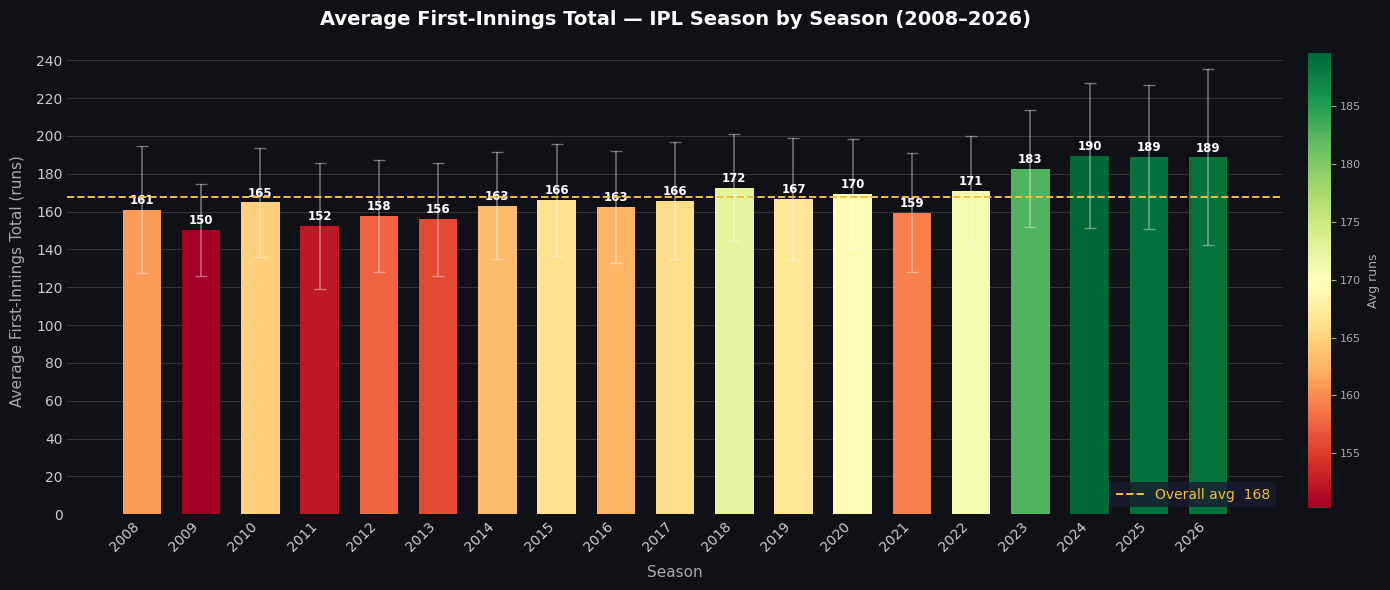

In [41]:
plot_avg_innings_total(1)


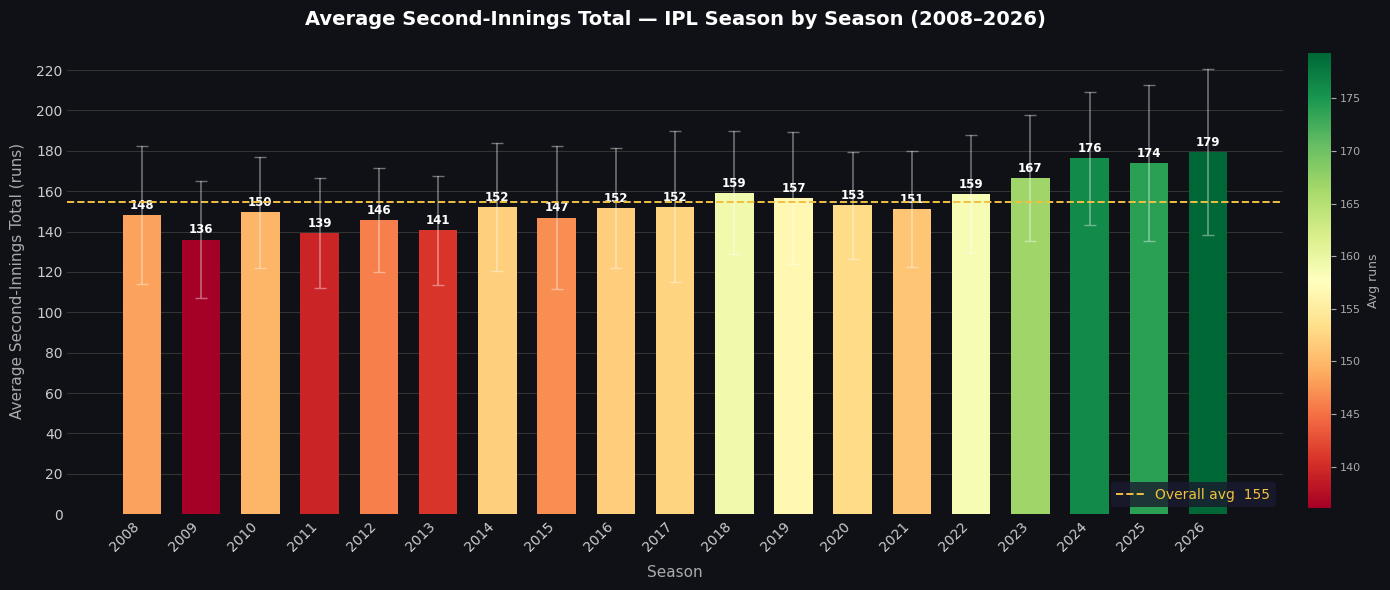

In [42]:
plot_avg_innings_total(2)


In [43]:
def plot_phase_runs(over_start, over_end, phase_name):
    """over_start/over_end are 0-indexed, inclusive."""
    phase = ball_by_ball_data[
        (ball_by_ball_data['innings'].isin([1, 2])) &
        (~ball_by_ball_data['is_super_over']) &
        (ball_by_ball_data['over_number'] >= over_start) &
        (ball_by_ball_data['over_number'] <= over_end)
    ]
    agg = (
        phase.groupby(['season_id', 'innings', 'match_id'])['total_runs'].sum()
        .reset_index()
        .groupby(['season_id', 'innings'])['total_runs'].mean()
        .unstack('innings')
    )
    agg.columns = ['Innings 1', 'Innings 2']
    seasons = agg.index.astype(str)
    x, w = np.arange(len(seasons)), 0.35

    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor('#0f1117')
    ax.set_facecolor('#0f1117')

    b1 = ax.bar(x - w/2, agg['Innings 1'], w, label='Innings 1', color='#4c9be8', zorder=3, edgecolor='none')
    b2 = ax.bar(x + w/2, agg['Innings 2'], w, label='Innings 2', color='#e8834c', zorder=3, edgecolor='none')

    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                f'{bar.get_height():.0f}', ha='center', va='bottom',
                fontsize=7.5, color='white', fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(seasons, rotation=45, ha='right', color='#cccccc', fontsize=10)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.tick_params(axis='y', colors='#cccccc', labelsize=10)
    ax.spines[:].set_visible(False)
    ax.tick_params(axis='both', length=0)
    ax.yaxis.grid(True, color='#333333', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    ax.set_xlabel('Season', color='#aaaaaa', fontsize=11, labelpad=8)
    ax.set_ylabel(f'Average {phase_name} Runs', color='#aaaaaa', fontsize=11, labelpad=8)
    ax.set_title(f'Average {phase_name} Runs per Innings — IPL 2008–2026',
                 color='white', fontsize=14, fontweight='bold', pad=16)
    ax.legend(facecolor='#1a1a2e', edgecolor='none', labelcolor='white', fontsize=10, loc='upper left')

    plt.tight_layout()
    plt.show()


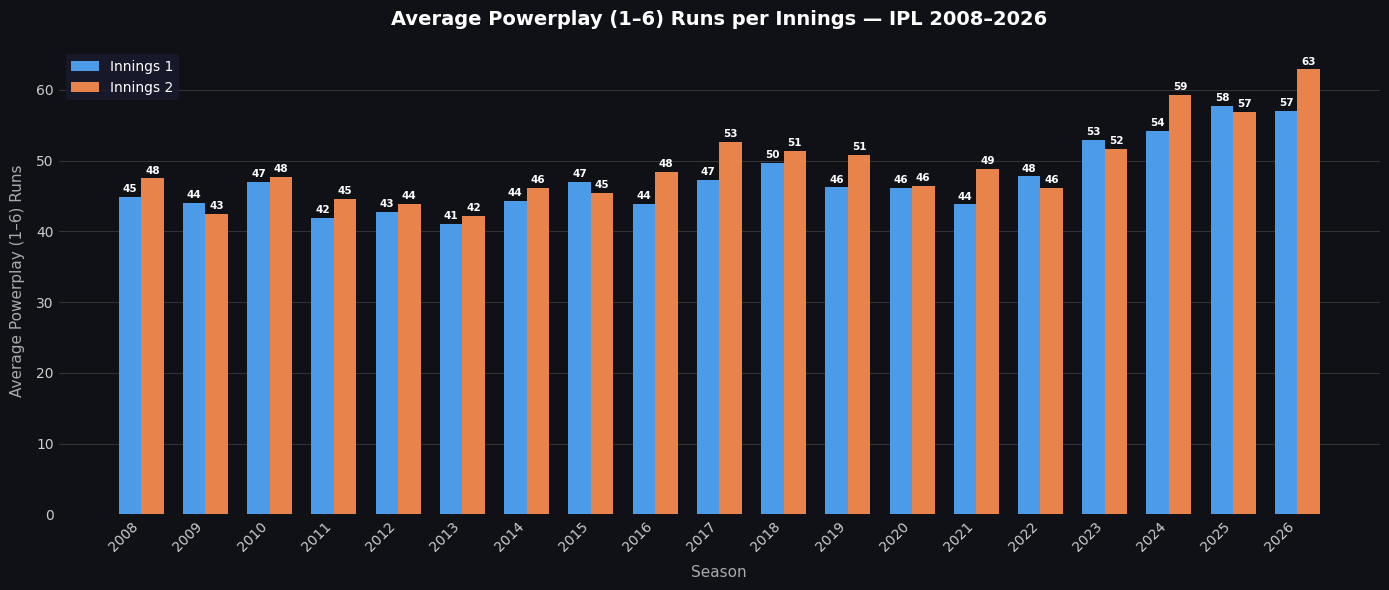

In [44]:
plot_phase_runs(0, 5, 'Powerplay (1–6)')  # overs 1–6


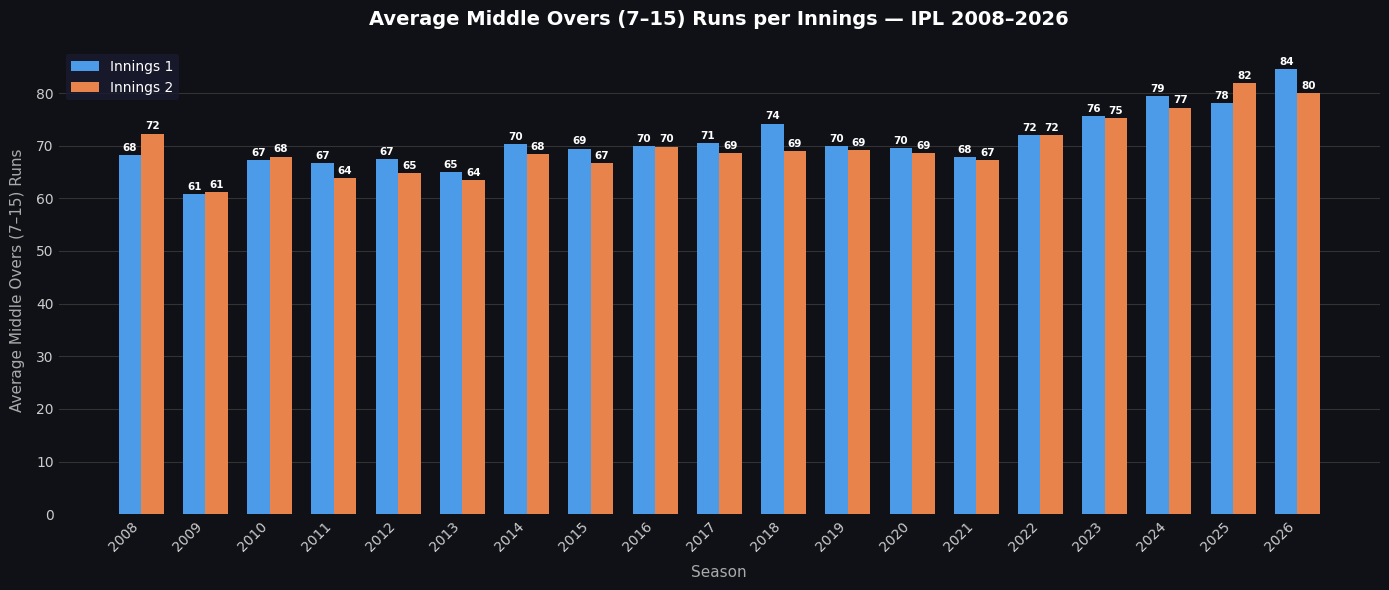

In [45]:
plot_phase_runs(6, 14, 'Middle Overs (7–15)')  # overs 7–15


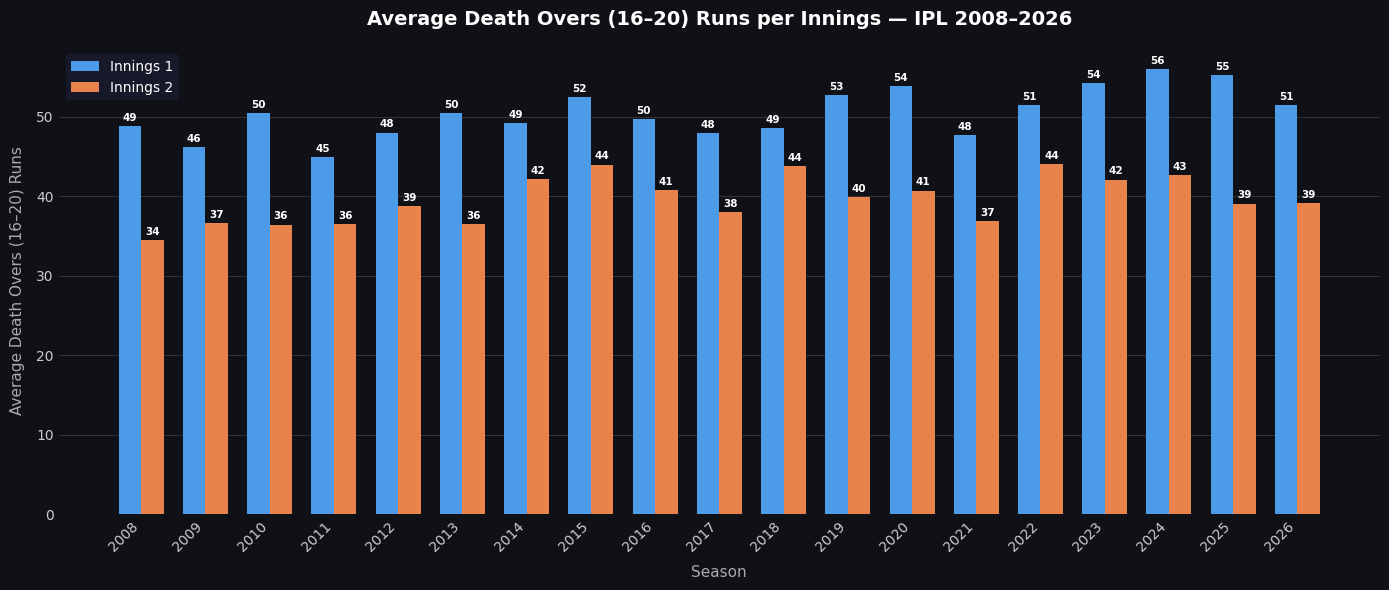

In [46]:
plot_phase_runs(15, 19, 'Death Overs (16–20)')  # overs 16–20


In [47]:
def plot_boundaries_per_season():
    df = ball_by_ball_data[
        (~ball_by_ball_data["is_super_over"]) &
        (ball_by_ball_data["innings"].isin([1, 2]))
    ]
    fours = df[df["batter_runs"] == 4].groupby("season_id").size()
    sixes = df[df["batter_runs"] == 6].groupby("season_id").size()
    match_counts = ipl_matches_data.groupby("season_id").size()

    seasons = sorted(set(fours.index) | set(sixes.index))
    fours_per_match = [fours.get(s, 0) / match_counts.get(s, 1) for s in seasons]
    sixes_per_match = [sixes.get(s, 0) / match_counts.get(s, 1) for s in seasons]
    season_labels = [str(s) for s in seasons]
    x = np.arange(len(seasons))
    w = 0.38

    fig, axes = plt.subplots(2, 1, figsize=(14, 12))
    fig.patch.set_facecolor("#0f1117")

    # --- Panel 1: Total 4s and 6s ---
    ax = axes[0]
    ax.set_facecolor("#0f1117")
    b1 = ax.bar(x - w/2, [fours.get(s, 0) for s in seasons], w,
               label="Fours", color="#4c9be8", zorder=3, edgecolor="none")
    b2 = ax.bar(x + w/2, [sixes.get(s, 0) for s in seasons], w,
               label="Sixes", color="#e85c4c", zorder=3, edgecolor="none")
    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
                f"{int(bar.get_height())}", ha="center", va="bottom",
                fontsize=7.5, color="white", fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(season_labels, rotation=45, ha="right", color="#cccccc", fontsize=10)
    ax.tick_params(axis="y", colors="#cccccc", labelsize=10)
    ax.spines[:].set_visible(False)
    ax.tick_params(axis="both", length=0)
    ax.yaxis.grid(True, color="#333333", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.set_ylabel("Total Boundaries", color="#aaaaaa", fontsize=11, labelpad=8)
    ax.set_title("Total Fours & Sixes per Season — IPL 2008–2026",
                 color="white", fontsize=14, fontweight="bold", pad=14)
    ax.legend(facecolor="#1a1a2e", edgecolor="none", labelcolor="white", fontsize=10)

    # --- Panel 2: Per-match averages ---
    ax2 = axes[1]
    ax2.set_facecolor("#0f1117")
    b3 = ax2.bar(x - w/2, fours_per_match, w,
                label="Fours / match", color="#4c9be8", zorder=3, edgecolor="none")
    b4 = ax2.bar(x + w/2, sixes_per_match, w,
                label="Sixes / match", color="#e85c4c", zorder=3, edgecolor="none")
    for bar in list(b3) + list(b4):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                 f"{bar.get_height():.1f}", ha="center", va="bottom",
                 fontsize=7.5, color="white", fontweight="bold")
    ax2.set_xticks(x)
    ax2.set_xticklabels(season_labels, rotation=45, ha="right", color="#cccccc", fontsize=10)
    ax2.tick_params(axis="y", colors="#cccccc", labelsize=10)
    ax2.spines[:].set_visible(False)
    ax2.tick_params(axis="both", length=0)
    ax2.yaxis.grid(True, color="#333333", linewidth=0.8, zorder=0)
    ax2.set_axisbelow(True)
    ax2.set_xlabel("Season", color="#aaaaaa", fontsize=11, labelpad=8)
    ax2.set_ylabel("Boundaries per Match", color="#aaaaaa", fontsize=11, labelpad=8)
    ax2.set_title("Average Fours & Sixes per Match — IPL 2008–2026",
                 color="white", fontsize=14, fontweight="bold", pad=14)
    ax2.legend(facecolor="#1a1a2e", edgecolor="none", labelcolor="white", fontsize=10)

    plt.tight_layout(pad=3)
    plt.show()


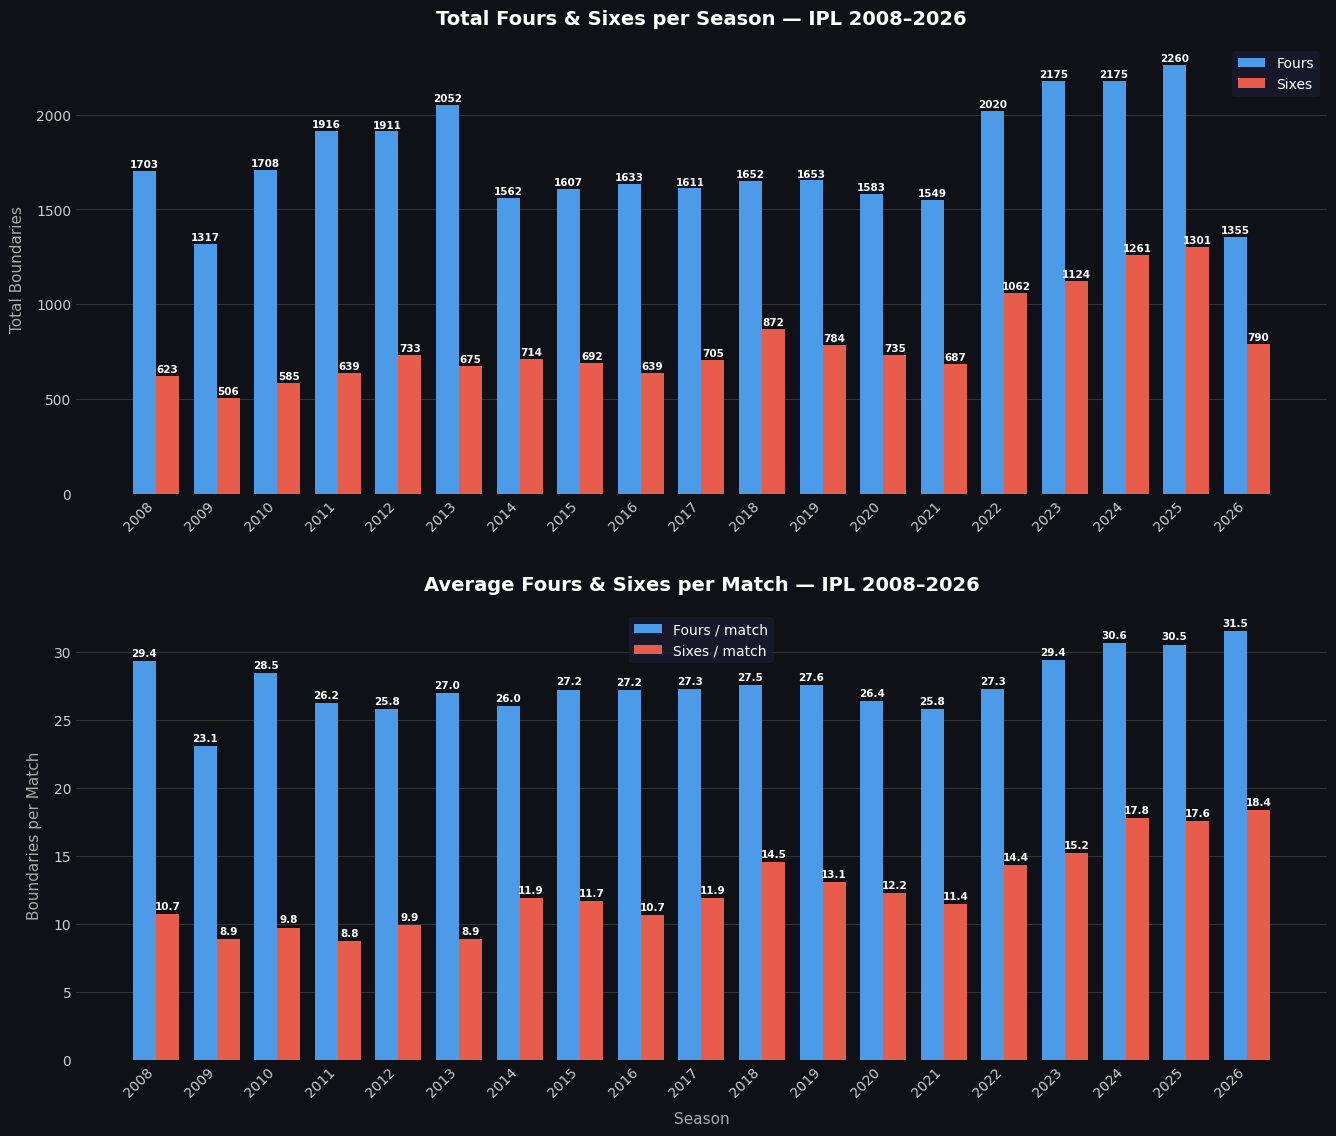

In [48]:
plot_boundaries_per_season()


In [49]:
def plot_six_to_four_ratio():
    df = ball_by_ball_data[
        (~ball_by_ball_data["is_super_over"]) &
        (ball_by_ball_data["innings"].isin([1, 2]))
    ]
    fours = df[df["batter_runs"] == 4].groupby("season_id").size()
    sixes = df[df["batter_runs"] == 6].groupby("season_id").size()
    seasons = sorted(set(fours.index) | set(sixes.index))
    ratio = [sixes.get(s, 0) / fours.get(s, 1) for s in seasons]
    season_labels = [str(s) for s in seasons]
    x = np.arange(len(seasons))

    norm = plt.Normalize(min(ratio), max(ratio))
    colors = [plt.cm.RdYlGn(norm(v)) for v in ratio]

    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor("#0f1117")
    ax.set_facecolor("#0f1117")

    bars = ax.bar(x, ratio, color=colors, width=0.65, zorder=3, edgecolor="none")
    for bar, val in zip(bars, ratio):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{val:.2f}", ha="center", va="bottom",
                fontsize=8.5, color="white", fontweight="bold")

    overall = sum(ratio) / len(ratio)
    ax.axhline(overall, color="#f0c040", linewidth=1.4, linestyle="--",
               zorder=5, label=f"Overall avg  {overall:.2f}")

    ax.set_xticks(x)
    ax.set_xticklabels(season_labels, rotation=45, ha="right", color="#cccccc", fontsize=10)
    ax.tick_params(axis="y", colors="#cccccc", labelsize=10)
    ax.spines[:].set_visible(False)
    ax.tick_params(axis="both", length=0)
    ax.yaxis.grid(True, color="#333333", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlabel("Season", color="#aaaaaa", fontsize=11, labelpad=8)
    ax.set_ylabel("Sixes per Four", color="#aaaaaa", fontsize=11, labelpad=8)
    ax.set_title("Six-to-Four Ratio by Season — IPL 2008–2026",
                 color="white", fontsize=14, fontweight="bold", pad=14)
    ax.legend(facecolor="#1a1a2e", edgecolor="none", labelcolor="#f0c040", fontsize=10, loc="upper left")

    sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.018, pad=0.02)
    cbar.set_label("Ratio", color="#aaaaaa", fontsize=9)
    cbar.ax.yaxis.set_tick_params(color="#aaaaaa", labelsize=8)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#aaaaaa")
    cbar.outline.set_visible(False)

    plt.tight_layout()
    plt.show()


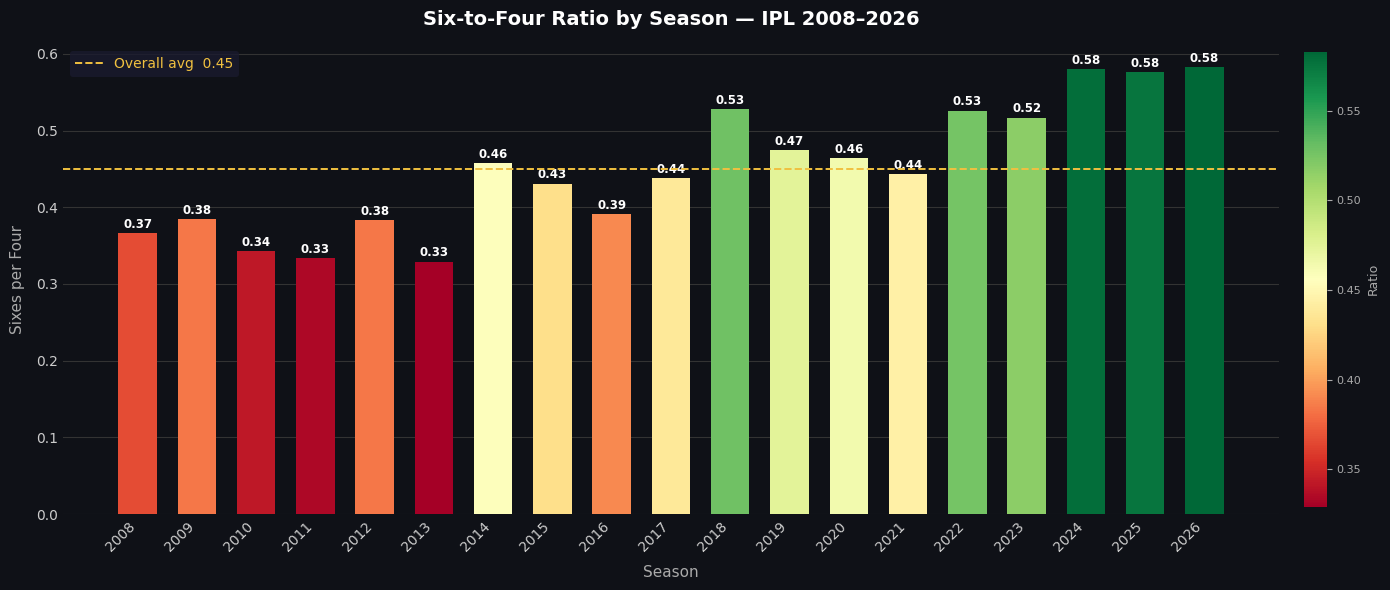

In [50]:
plot_six_to_four_ratio()


In [51]:
def plot_close_matches():
    """
    Close match criteria (a match qualifies if ANY holds):
      - Won by ≤ 10 runs            (tight batting-first win)
      - Won by ≤ 2 wickets          (barely-scraped chase)
      - Super over                   (match tied in 20 overs)
      - Last-over finish             (innings-2 had deliveries in over 19 — 20th over)

    Each qualifying match is assigned ONE label for the stacked bar, in priority order:
      Super Over > 1-Wicket Win > Last-Over Finish > 2-Wicket Win > Won by ≤5 > Won by 6-10
    """
    BG = '#0f1117'
    PALETTE = {
        'Super Over':        '#ff6b6b',
        '1-Wicket Win':      '#ff9f43',
        'Last-Over Finish':  '#48dbfb',
        '2-Wicket Win':      '#feca57',
        'Won by ≤5 Runs':    '#1dd1a1',
        'Won by 6–10 Runs':  '#54a0ff',
    }

    # --- build criteria sets ---
    super_over_ids = set(
        ball_by_ball_data[ball_by_ball_data['is_super_over']]['match_id'].unique()
    )
    last_over_ids = set(
        ball_by_ball_data[
            (ball_by_ball_data['innings'] == 2) &
            (~ball_by_ball_data['is_super_over']) &
            (ball_by_ball_data['over_number'] == 19)
        ]['match_id'].unique()
    )

    matches = ipl_matches_data[ipl_matches_data['result'] == 'win'].copy()

    def classify(row):
        mid = row['match_id']
        wr  = row['win_by_runs']
        ww  = row['win_by_wickets']
        if mid in super_over_ids:                    return 'Super Over'
        if pd.notna(ww) and ww == 1:                 return '1-Wicket Win'
        if mid in last_over_ids:                     return 'Last-Over Finish'
        if pd.notna(ww) and ww == 2:                 return '2-Wicket Win'
        if pd.notna(wr) and 1 <= wr <= 5:            return 'Won by ≤5 Runs'
        if pd.notna(wr) and 6 <= wr <= 10:           return 'Won by 6–10 Runs'
        return None

    matches['close_type'] = matches.apply(classify, axis=1)
    close = matches[matches['close_type'].notna()]

    # season-level counts
    season_total = (
        ipl_matches_data[ipl_matches_data['result'].isin(['win', 'tie'])]
        .groupby('season_id').size().rename('total')
    )
    stacked = (
        close.groupby(['season_id', 'close_type']).size()
        .unstack('close_type', fill_value=0)
        .reindex(columns=list(PALETTE.keys()), fill_value=0)
        .reindex(season_total.index, fill_value=0)
    )
    total_close = stacked.sum(axis=1)
    pct_close   = (total_close / season_total * 100).fillna(0)

    seasons = [str(s) for s in stacked.index]
    x = np.arange(len(seasons))

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(15, 13),
        gridspec_kw={'height_ratios': [2.5, 1]}
    )
    fig.patch.set_facecolor(BG)

    # --- Panel 1: stacked bar ---
    ax1.set_facecolor(BG)
    bottom = np.zeros(len(x))
    for cat, color in PALETTE.items():
        vals = stacked[cat].values
        bars = ax1.bar(x, vals, bottom=bottom, label=cat, color=color,
                       width=0.65, zorder=3, edgecolor='none')
        for bar, val in zip(bars, vals):
            if val >= 2:
                ax1.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    str(int(val)), ha='center', va='center',
                    fontsize=7.5, color='#0f1117', fontweight='bold'
                )
        bottom += vals

    for i, tot in enumerate(total_close):
        if tot > 0:
            ax1.text(i, tot + 0.25, str(int(tot)),
                     ha='center', va='bottom', fontsize=9,
                     color='white', fontweight='bold')

    ax1.set_xticks(x)
    ax1.set_xticklabels(seasons, rotation=45, ha='right', color='#cccccc', fontsize=10)
    ax1.tick_params(axis='y', colors='#cccccc', labelsize=10)
    ax1.spines[:].set_visible(False)
    ax1.tick_params(axis='both', length=0)
    ax1.yaxis.grid(True, color='#333333', linewidth=0.8, zorder=0)
    ax1.set_axisbelow(True)
    ax1.set_ylabel('Close Matches', color='#aaaaaa', fontsize=11, labelpad=8)
    ax1.set_title(
        'Close Matches per IPL Season  (2008–2026)\n'
        '≤10-run win  |  ≤2-wicket win  |  Super over  |  Last-over finish',
        color='white', fontsize=13, fontweight='bold', pad=14
    )
    ax1.legend(
        facecolor='#1a1a2e', edgecolor='none', labelcolor='white',
        fontsize=9, loc='upper right', ncol=3
    )

    # --- Panel 2: % line ---
    ax2.set_facecolor(BG)
    ax2.fill_between(x, pct_close.values, alpha=0.15, color='#f0c040', zorder=2)
    ax2.plot(x, pct_close.values, color='#f0c040', linewidth=2.2,
             marker='o', markersize=6, zorder=4)
    for i, val in enumerate(pct_close):
        ax2.text(i, val + 1.5, f'{val:.0f}%',
                 ha='center', va='bottom', fontsize=8,
                 color='#f0c040', fontweight='bold')

    avg_pct = pct_close.mean()
    ax2.axhline(avg_pct, color='#888888', linewidth=1.2, linestyle='--',
                label=f'Season avg  {avg_pct:.0f}%')

    ax2.set_xticks(x)
    ax2.set_xticklabels(seasons, rotation=45, ha='right', color='#cccccc', fontsize=10)
    ax2.tick_params(axis='y', colors='#cccccc', labelsize=10)
    ax2.spines[:].set_visible(False)
    ax2.tick_params(axis='both', length=0)
    ax2.yaxis.grid(True, color='#333333', linewidth=0.8, zorder=0)
    ax2.set_axisbelow(True)
    ax2.set_ylabel('% of Matches', color='#aaaaaa', fontsize=11, labelpad=8)
    ax2.set_xlabel('Season', color='#aaaaaa', fontsize=11, labelpad=8)
    ax2.legend(facecolor='#1a1a2e', edgecolor='none', labelcolor='#888888', fontsize=9)

    plt.tight_layout(pad=3)
    plt.show()


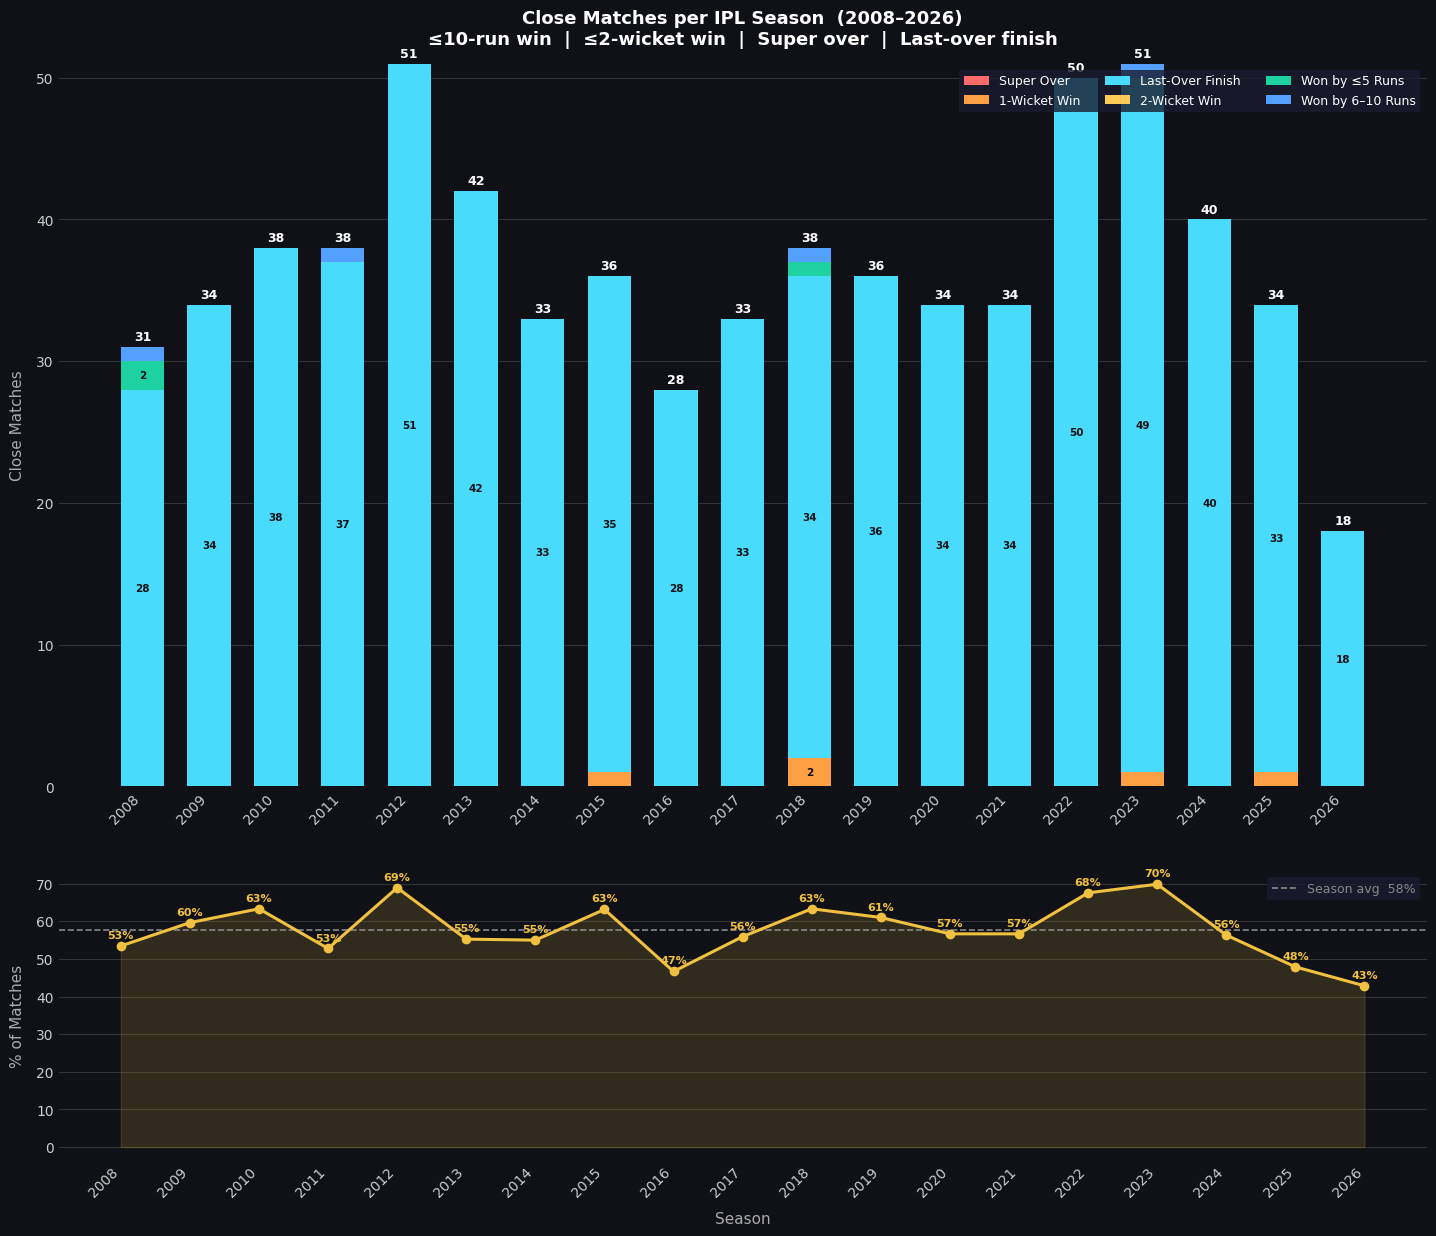

In [52]:
plot_close_matches()